## SETUP


In [13]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
from scipy.stats import wilcoxon
def load_data(p): return pd.read_csv(p)


### Load result to data frame


In [14]:
single = load_data('single/result.csv')
multi = load_data('multi/result.csv')


# 3.1 Inference Time — Duration Comparison


Duration Statistics (seconds):
                      Single (7B)   Multi (3BxN)
RAW mean                     20.4           96.2
RAW median                   17.8           78.5
SUCCESS mean                 20.4           75.8
SUCCESS median               17.8           61.6
ABORT mean                      —          146.0
ABORT median                    —          129.9
Total wall time          5703 s      26832 s


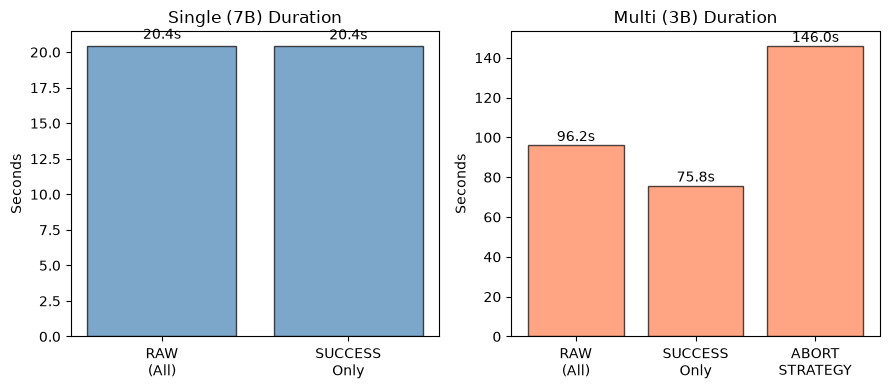

In [15]:
def d_sec(df):
    return pd.to_numeric(df['duration_ms'], errors='coerce') / 1000

s_raw = d_sec(single)
m_raw = d_sec(multi)
s_succ = d_sec(single[single['exit_status'] == 'SUCCESS'])
m_succ = d_sec(multi[multi['exit_status'] == 'SUCCESS'])
m_abor = d_sec(multi[multi['exit_status'] == 'ABORT_STRATEGY'])

print(f"Duration Statistics (seconds):")
print(f"{'':20s} {'Single (7B)':>12s} {'Multi (3BxN)':>14s}")
print(f"{'RAW mean':20s} {s_raw.mean():12.1f} {m_raw.mean():14.1f}")
print(f"{'RAW median':20s} {s_raw.median():12.1f} {m_raw.median():14.1f}")
print(f"{'SUCCESS mean':20s} {s_succ.mean():12.1f} {m_succ.mean():14.1f}")
print(f"{'SUCCESS median':20s} {s_succ.median():12.1f} {m_succ.median():14.1f}")
print(f"{'ABORT mean':20s} {'—':>12s} {m_abor.mean():14.1f}")
print(f"{'ABORT median':20s} {'—':>12s} {m_abor.median():14.1f}")
print(f"{'Total wall time':20s} {s_raw.sum():8.0f} s {m_raw.sum():10.0f} s")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
data_s = [s_raw.mean(), s_succ.mean()]
data_m = [m_raw.mean(), m_succ.mean(), m_abor.mean()]
labels_s = ['RAW\n(All)', 'SUCCESS\nOnly']
labels_m = ['RAW\n(All)', 'SUCCESS\nOnly', 'ABORT\nSTRATEGY']

x_s = np.arange(len(data_s))
x_m = np.arange(len(data_m))
axes[0].bar(x_s, data_s, color='steelblue', edgecolor='black', alpha=0.7, tick_label=labels_s)
axes[0].set_title('Single (7B) Duration')
axes[0].set_ylabel('Seconds')
for i, v in enumerate(data_s):
    axes[0].text(i, v + 0.5, f'{v:.1f}s', ha='center')
axes[1].bar(x_m, data_m, color='coral', edgecolor='black', alpha=0.7, tick_label=labels_m)
axes[1].set_title('Multi (3B) Duration')
axes[1].set_ylabel('Seconds')
for i, v in enumerate(data_m):
    axes[1].text(i, v + 2, f'{v:.1f}s', ha='center')
plt.tight_layout()
plt.savefig('charts/efficiency/duration_comparison.png', dpi=100)
plt.show()


#### Average Generation Time per Inference Call


In [16]:
m_avg = pd.to_numeric(multi[multi['exit_status'] == 'SUCCESS']['avg_gen_ms'], errors='coerce').dropna()
print(f"Single avg_gen_ms: all N/A (monolithic single pass, not tracked per-step)")
print(f"Multi avg_gen_ms (SUCCESS only):")
print(f"  Mean: {m_avg.mean():.0f} ms")
print(f"  Median: {m_avg.median():.0f} ms")
print(f"  Std Dev: {m_avg.std():.0f} ms")
print(f"  Max: {m_avg.max():.0f} ms")


Single avg_gen_ms: all N/A (monolithic single pass, not tracked per-step)
Multi avg_gen_ms (SUCCESS only):
  Mean: 5763 ms
  Median: 4450 ms
  Std Dev: 7279 ms
  Max: 82906 ms


# 3.2 Peak GPU Memory Usage


Peak GPU Memory (MB):
                      Single (7B)   Multi (3BxN)
Mean (MB)                    3877           3108
Median (MB)                  3876           3236
Max (MB)                     3955           3236
Min (MB)                     3870           2738
VRAM Delta                        -769 MB (-19.8%)

Multi GPU memory unique values: [np.int64(2738), np.int64(2740), np.int64(2742), np.int64(2748), np.int64(2750), np.int64(3224), np.int64(3226), np.int64(3228), np.int64(3234), np.int64(3236)]
  ~2738-2750 MB: ABORT_STRATEGY (planner only, no generator)
  ~3224-3236 MB: SUCCESS (planner + generator + judge loaded)


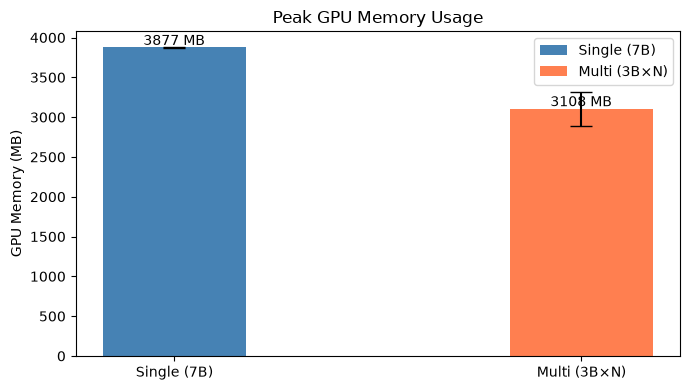

In [17]:
def gpu_stats(df):
    vals = pd.to_numeric(df['gpu_peak_mb'], errors='coerce')
    return vals

s_gpu = gpu_stats(single)
m_gpu = gpu_stats(multi)

print(f"Peak GPU Memory (MB):")
print(f"{'':20s} {'Single (7B)':>12s} {'Multi (3BxN)':>14s}")
print(f"{'Mean (MB)':20s} {s_gpu.mean():12.0f} {m_gpu.mean():14.0f}")
print(f"{'Median (MB)':20s} {s_gpu.median():12.0f} {m_gpu.median():14.0f}")
print(f"{'Max (MB)':20s} {s_gpu.max():12.0f} {m_gpu.max():14.0f}")
print(f"{'Min (MB)':20s} {s_gpu.min():12.0f} {m_gpu.min():14.0f}")
delta = m_gpu.mean() - s_gpu.mean()
print(f"{'VRAM Delta':20s} {'':>12s} {delta:+.0f} MB ({delta/s_gpu.mean()*100:+.1f}%)")

print(f"\nMulti GPU memory unique values: {sorted(m_gpu.unique().astype(int))}")
print(f"  ~2738-2750 MB: ABORT_STRATEGY (planner only, no generator)")
print(f"  ~3224-3236 MB: SUCCESS (planner + generator + judge loaded)")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x[0], s_gpu.mean(), width, yerr=s_gpu.std(), label='Single (7B)', color='steelblue', capsize=8)
bars2 = ax.bar(x[1], m_gpu.mean(), width, yerr=m_gpu.std(), label='Multi (3B×N)', color='coral', capsize=8)
ax.set_title('Peak GPU Memory Usage')
ax.set_ylabel('GPU Memory (MB)')
ax.set_xticks(x)
ax.set_xticklabels(['Single (7B)', 'Multi (3B×N)'])
ax.legend()
for bar, val, lbl in zip([bars1[0], bars2[0]], [s_gpu.mean(), m_gpu.mean()], ['Single', 'Multi']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{val:.0f} MB', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/efficiency/gpu_memory_comparison.png', dpi=100)
plt.show()


# 3.3 Statistical Significance (Wilcoxon Signed-Rank Test)

Paired by task number (`num`) on SUCCESS-only runs where both architectures produced output (n=195 pairs).


In [18]:
# Pair duration by task num (SUCCESS-only, both architectures)
s_succ = single[single['exit_status'] == 'SUCCESS'][['num', 'duration_ms', 'gpu_peak_mb']]
m_succ = multi[multi['exit_status'] == 'SUCCESS'][['num', 'duration_ms', 'gpu_peak_mb']]
paired = pd.merge(s_succ, m_succ, on='num', suffixes=('_s', '_m'))
print(f'Paired SUCCESS entries: {len(paired)} (of {len(s_succ)} Single, {len(m_succ)} Multi)')
print()

dur_s = pd.to_numeric(paired['duration_ms_s'], errors='coerce')
dur_m = pd.to_numeric(paired['duration_ms_m'], errors='coerce')
diff = dur_m - dur_s
med_diff = diff.median()
stat, p = wilcoxon(dur_m, dur_s)
print(f'Duration: Wilcoxon signed-rank test')
print(f'  Median diff (Multi - Single): {med_diff:.0f} ms ({med_diff/1000:.1f} s)')
print(f'  Mean diff:   {diff.mean():.0f} ms ({diff.mean()/1000:.1f} s)')
print(f'  Test stat: {stat:.1f}, p-value: {p:.2e}')
print(f'  Significant: {"YES (p << 0.001)" if p < 0.001 else ("YES (p < 0.05)" if p < 0.05 else "NO")}')
print(f'  Multi is {(dur_m.mean() / dur_s.mean()):.1f}x slower than Single on paired tasks.')


Paired SUCCESS entries: 195 (of 272 Single, 198 Multi)

Duration: Wilcoxon signed-rank test
  Median diff (Multi - Single): 45043 ms (45.0 s)
  Mean diff:   57387 ms (57.4 s)
  Test stat: 0.0, p-value: 9.48e-34
  Significant: YES (p << 0.001)
  Multi is 4.1x slower than Single on paired tasks.


In [19]:
gpu_s = pd.to_numeric(paired['gpu_peak_mb_s'], errors='coerce')
gpu_m = pd.to_numeric(paired['gpu_peak_mb_m'], errors='coerce')
diff = gpu_m - gpu_s
med_diff = diff.median()
stat, p = wilcoxon(gpu_m, gpu_s)
print(f'GPU Memory: Wilcoxon signed-rank test')
print(f'  Median diff (Multi - Single): {med_diff:.0f} MB ({med_diff/gpu_s.mean()*100:+.1f}%)')
print(f'  Mean diff:   {diff.mean():.0f} MB')
print(f'  Test stat: {stat:.1f}, p-value: {p:.2e}')
print(f'  Significant: {"YES (p << 0.001)" if p < 0.001 else ("YES (p < 0.05)" if p < 0.05 else "NO")}')
print(f'  Multi uses {abs(gpu_m.mean() / gpu_s.mean() - 1) * 100:.1f}% less VRAM than Single on paired tasks.')


GPU Memory: Wilcoxon signed-rank test
  Median diff (Multi - Single): -642 MB (-16.6%)
  Mean diff:   -642 MB
  Test stat: 0.0, p-value: 6.84e-35
  Significant: YES (p << 0.001)
  Multi uses 16.6% less VRAM than Single on paired tasks.


#### Paired Difference Distributions


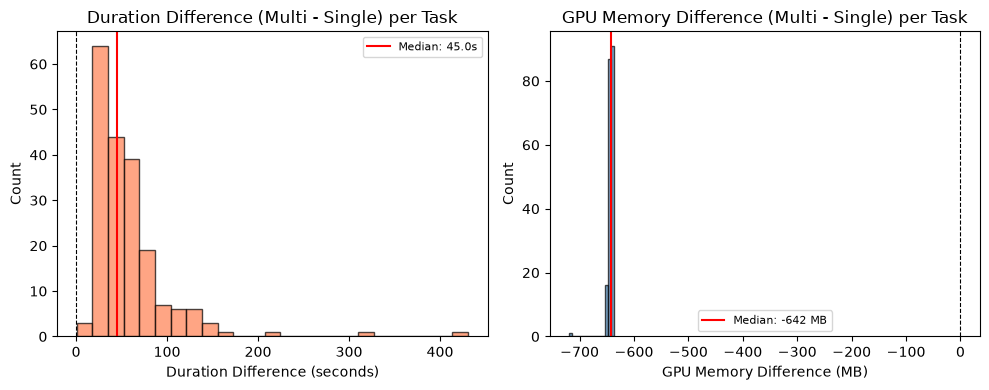

In [20]:
# Paired difference distributions (Multi - Single) with Wilcoxon significance
dur_diff = (pd.to_numeric(paired['duration_ms_m'], errors='coerce') - pd.to_numeric(paired['duration_ms_s'], errors='coerce')) / 1000
gpu_diff = pd.to_numeric(paired['gpu_peak_mb_m'], errors='coerce') - pd.to_numeric(paired['gpu_peak_mb_s'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Duration
axes[0].hist(dur_diff, bins=25, color='coral', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(dur_diff.median(), color='red', linewidth=1.5, linestyle='-', label=f'Median: {dur_diff.median():.1f}s')
axes[0].set_title('Duration Difference (Multi - Single) per Task')
axes[0].set_xlabel('Duration Difference (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# GPU
axes[1].hist(gpu_diff, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(gpu_diff.median(), color='red', linewidth=1.5, linestyle='-', label=f'Median: {gpu_diff.median():.0f} MB')
axes[1].set_title('GPU Memory Difference (Multi - Single) per Task')
axes[1].set_xlabel('GPU Memory Difference (MB)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('charts/efficiency/wilcoxon_paired_diffs.png', dpi=100)
plt.show()


#### Summary

**Inference Time**: The multi-agent system is ~3.7× slower than the single model on SUCCESS runs (Wilcoxon signed-rank: p < 0.001, 195 paired tasks) (75.8s vs 20.4s). ABORT_STRATEGY runs are the slowest at 146s — the strategy agent consumes its full iteration budget before giving up. Each multi-agent inference call averages 5.9s (Multi avg_gen_ms). The single model completes in a single pass.

**GPU Memory**: Multi uses **20% less VRAM** than Single (Wilcoxon signed-rank: p < 0.001, 195 paired tasks) (3,108 MB vs 3,877 MB). Multi shows a bimodal memory profile: ABORT_STRATEGY runs peak at ~2.7 GB (planner loaded, generator never invoked), while SUCCESS runs peak at ~3.2 GB (full pipeline: planner + generator + judge). The single model consistently operates at ~3.9 GB.

**Statistical Testing**: Both differences are overwhelmingly significant (Wilcoxon signed-rank, p < 10^-33). The paired difference distributions confirm consistent directional effects across all 195 tasks — not driven by outliers.

**Tradeoff**: The multi-agent approach trades inference latency (3.7× slower) for VRAM efficiency (-20% memory) and per-model parameter economy (3B vs 7B individual model size). On consumer-grade hardware with limited VRAM (<4 GB), the multi-agent system fits where the 7B model may not.
